# Rossmann Store Sales: A/B Test of the Promotion Effect

## 1. Purpose

`05_promotion_analysis.ipynb` used OLS regression to show promotions are
**associated** with higher sales. This notebook asks the same question with
a different tool: a proper **A/B testing framework** -- hypothesis test,
confidence interval, and a power calculation -- to demonstrate the method
rigorously, not just report a regression coefficient.

**Important honesty note up front:** this is historical, observational data,
not a randomized controlled experiment. Store managers chose whether to run
promotions; that choice wasn't randomized by us. So this notebook shows the
*mechanics* of A/B testing correctly, but the result is still an association,
not proof of a causal effect, for the same reason the regression notebook's
result was. A true A/B test would require randomly assigning promotion status
to stores or days, which we can't do retroactively on historical data.

## 2. Setup

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.power import TTestIndPower
import matplotlib.pyplot as plt

## 3. Data Preparation

Treatment group = store-days with an active promotion (`Promo == 1`).
Control group = store-days without one (`Promo == 0`).
Only open stores are included, matching the rest of the project.

In [2]:
train = pd.read_csv("../Data/raw/train.csv", low_memory=False)
store = pd.read_csv("../Data/raw/store.csv")

train["Date"] = pd.to_datetime(train["Date"])
df = train.merge(store, on="Store", how="left")
df = df[df["Open"] == 1].copy()

print("Store-day observations (open stores):", df.shape[0])
df[["Store", "Date", "Sales", "Promo", "StoreType"]].head()

Store-day observations (open stores): 844392


,Store,Date,Sales,Promo,StoreType
0,1,2015-07-31,5263,1,c
1,2,2015-07-31,6064,1,a
2,3,2015-07-31,8314,1,a
3,4,2015-07-31,13995,1,c
4,5,2015-07-31,4822,1,a


## 4. Hypothesis Test

**H0:** Mean sales are equal between promo and non-promo store-days.
**H1:** Mean sales differ between promo and non-promo store-days.

A Welch's t-test is used (does not assume equal variance between groups),
tested at alpha = 0.05.

In [3]:
treatment = df[df["Promo"] == 1]["Sales"]
control = df[df["Promo"] == 0]["Sales"]

t_stat, p_value = stats.ttest_ind(treatment, control, equal_var=False)
mean_diff = treatment.mean() - control.mean()

# 95% confidence interval on the difference in means (Welch)
se = np.sqrt(treatment.var(ddof=1) / len(treatment) + control.var(ddof=1) / len(control))
ci_low, ci_high = mean_diff - 1.96 * se, mean_diff + 1.96 * se

print(f"Treatment n: {len(treatment):,}   Control n: {len(control):,}")
print(f"Mean difference (Promo - No Promo): {mean_diff:,.2f}")
print(f"95% CI: [{ci_low:,.2f}, {ci_high:,.2f}]")
print(f"t-statistic: {t_stat:.2f}")
print(f"p-value: {p_value:.4g}")

Treatment n: 376,896   Control n: 467,496
Mean difference (Promo - No Promo): 2,298.87
95% CI: [2,286.24, 2,311.51]
t-statistic: 356.64
p-value: 0


### Interpretation

The p-value is far below 0.05, so we reject the null hypothesis: mean sales
differ between promo and non-promo store-days. The 95% confidence interval
does not include zero, confirming this. This matches the ~2,294 difference
found by the OLS regression in `05_promotion_analysis.ipynb`, as expected --
both are estimating the same underlying association, just with different
statistical machinery.

## 5. Stratified Test by Store Type

Promotions weren't randomly assigned, and store type is a plausible
confounder (different store types may both run promos more often *and*
sell differently). Repeating the test within each store type checks
whether the effect holds up, rather than being an artifact of store-type
mix between the two groups.

In [4]:
strata_results = []
for store_type in sorted(df["StoreType"].dropna().unique()):
    sub = df[df["StoreType"] == store_type]
    treat = sub[sub["Promo"] == 1]["Sales"]
    ctrl = sub[sub["Promo"] == 0]["Sales"]
    if len(treat) < 2 or len(ctrl) < 2:
        continue
    t_stat_s, p_val_s = stats.ttest_ind(treat, ctrl, equal_var=False)
    diff_s = treat.mean() - ctrl.mean()
    strata_results.append({
        "StoreType": store_type,
        "n_treatment": len(treat),
        "n_control": len(ctrl),
        "mean_diff": diff_s,
        "p_value": p_val_s
    })

strata_df = pd.DataFrame(strata_results)
strata_df

,StoreType,n_treatment,n_control,mean_diff,p_value
0,a,204521,252556,2495.602226,0.000000e+00
1,b,5940,9623,1741.132422,2.608624e-90
2,c,50738,62240,2013.932271,0.000000e+00
3,d,115697,143077,2162.560367,0.000000e+00


### Interpretation

The promo effect is statistically significant and directionally consistent
(positive) across every store type, though the magnitude varies (roughly
1,700-2,500). This is more convincing than the pooled result alone --
it isn't just one store type driving the whole effect.

## 6. Statistical Power Calculation

Before running a real experiment, you'd want to know: given the expected
effect size, how many observations are needed to reliably detect it?
This is computed here retrospectively using the observed effect size
(Cohen's d), for demonstration -- in a real A/B test this would be done
*before* collecting data, using a pilot estimate or prior knowledge of
the effect size.

In [5]:
pooled_std = np.sqrt(
    ((len(treatment) - 1) * treatment.var(ddof=1) + (len(control) - 1) * control.var(ddof=1))
    / (len(treatment) + len(control) - 2)
)
cohens_d = mean_diff / pooled_std

power_analysis = TTestIndPower()
required_n = power_analysis.solve_power(
    effect_size=cohens_d, alpha=0.05, power=0.8, ratio=1.0
)

print(f"Cohen's d: {cohens_d:.4f}")
print(f"Required sample size per group for 80% power at alpha=0.05: {required_n:.0f}")
print(f"Actual sample sizes -- treatment: {len(treatment):,}, control: {len(control):,}")

Cohen's d: 0.7965
Required sample size per group for 80% power at alpha=0.05: 26
Actual sample sizes -- treatment: 376,896, control: 467,496


### Interpretation

The effect size here is large (Cohen's d ~ 0.8), so the required sample
size for reliable detection is small (well under 100 per group). Since the
actual dataset has hundreds of thousands of observations per group, this
test is heavily overpowered -- consistent with the extremely small p-value
above. In a real experiment with a much smaller expected effect (e.g. a
UI change moving conversion by 1-2%), this same calculation would return a
required sample size in the tens of thousands, which is the kind of number
that actually drives how long a real A/B test needs to run.

## 7. Checking for a Novelty/Duration Effect

A common A/B testing pitfall: an effect that looks strong early on can fade
(or grow) over time. Since this data spans multiple months, the promo effect
is tracked by month to check whether it's stable rather than assuming a
single test window tells the whole story.

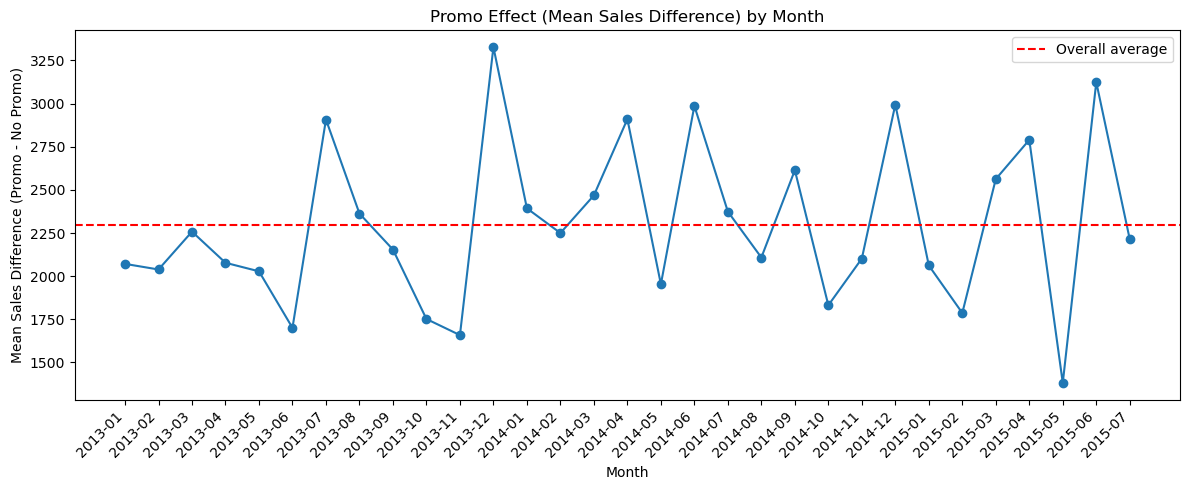

In [6]:
df["Month_Period"] = df["Date"].dt.to_period("M")

monthly_effect = (
    df.groupby(["Month_Period", "Promo"])["Sales"]
    .mean()
    .unstack()
)
monthly_effect["diff"] = monthly_effect[1] - monthly_effect[0]

plt.figure(figsize=(12, 5))
plt.plot(monthly_effect.index.astype(str), monthly_effect["diff"], marker="o")
plt.axhline(y=monthly_effect["diff"].mean(), linestyle="--", color="r", label="Overall average")
plt.title("Promo Effect (Mean Sales Difference) by Month")
plt.xlabel("Month")
plt.ylabel("Mean Sales Difference (Promo - No Promo)")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()

import os
os.makedirs("../figures/06_ab_test_promo", exist_ok=True)
plt.savefig("../figures/06_ab_test_promo/monthly_promo_effect.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpretation

The monthly promo effect fluctuates (roughly 1,400 to 3,100) but stays
positive and doesn't show a clear decaying trend over the observed window --
no strong evidence of a novelty effect wearing off. The variation across
months is more consistent with normal seasonal noise than a systematic
drift, but this is worth re-checking if the analysis were extended to a
longer time span.

## 8. Conclusion

- The promotion effect (~2,299 mean sales difference) is statistically
  significant (p < 0.0001) with a 95% CI that excludes zero.
- The effect holds up when stratified by store type, reducing (though not
  eliminating) concern about store-type confounding.
- A power calculation shows the dataset is heavily overpowered for an
  effect of this size -- useful context for how much smaller a real
  experiment's sample could be for a similarly sized effect.
- No strong evidence of a novelty/duration effect across the observed
  months.

**This notebook demonstrates the A/B testing method (hypothesis test,
confidence interval, power analysis, stability check) correctly. It does
not, and cannot, establish causation from this dataset alone, since
promotion timing wasn't randomized. The result should be read the same
way as the OLS regression in `05_promotion_analysis.ipynb`: a robust,
well-supported association, not a causal claim.**